# Corrected Study: Cochleagram Spectral Mapping

## Corrections from `marvins_cooch.ipynb`

| # | Issue | Fix |
|---|-------|-----|
| 1 | Cochleagrams looked nearly identical | Source: N=8, bw=8.0 (8-ch CI sim) vs Target: N=40, bw=1.0 |
| 2 | Shuffled split leaked temporal context | Block split only (80/20) |
| 3 | `E_hat` overwritten 3 times | Renamed to `E_hat_ridge`, `E_hat_rf`, `E_hat_mlp` |
| 4 | MLP had no early stopping | Added `early_stopping=True`, `n_iter_no_change=15` |
| 5 | Only MAE reported | Added R² and reconstruction SNR (dB) |


## 1. Setup

In [49]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve, hilbert
from scipy.interpolate import interp1d
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

y, fs = librosa.load('../KU.wav', sr=None)
if fs != 16000:
    y = librosa.resample(y, orig_sr=fs, target_sr=16000)
    fs = 16000
y = y / (np.max(np.abs(y)) + 1e-9)
print(f'Loaded audio: fs={fs}, samples={len(y)}')


Loaded audio: fs=16000, samples=2563855


In [50]:
def erb_hz(f):
    return 24.7 * (4.37 * f / 1000 + 1)

def erb_scale(f):
    return 21.4 * np.log10(1 + 0.00437 * f)

def inv_erb(e):
    return (10**(e / 21.4) - 1) / 0.00437

def erb_centers(fmin, fmax, n):
    e = np.linspace(erb_scale(fmin), erb_scale(fmax), n)
    return inv_erb(e)

def gammatone(fs, fc, n=4, dur=0.08, bw_mult=1.0):
    t = np.arange(0, int(dur * fs)) / fs
    b = bw_mult * 1.019 * erb_hz(fc)
    g = t**(n - 1) * np.exp(-2 * np.pi * b * t) * np.cos(2 * np.pi * fc * t)
    g /= (np.sqrt(np.sum(g**2)) + 1e-12)
    return g

def build_cochleagram(sig, fs, fmin=100, fmax=8000, N=32, bw_mult=1.0, hop_ms=10):
    hop = int((hop_ms / 1000) * fs)
    centers = erb_centers(fmin, fmax, N)
    bands = []
    for fc in centers:
        g = gammatone(fs, fc, bw_mult=bw_mult)
        y_filt = fftconvolve(sig, g, mode='same')
        env = np.log1p(np.abs(hilbert(y_filt)))
        bands.append(env[::hop])
    return np.vstack(bands), centers, hop

def recon_snr(C_pred, C_true):
    signal_power = np.mean(C_true**2)
    noise_power  = np.mean((C_true - C_pred)**2)
    return 10 * np.log10(signal_power / (noise_power + 1e-12))

def evaluate(C_pred, C_true, name):
    mae = np.mean(np.abs(C_pred - C_true))
    r2  = 1 - np.sum((C_true - C_pred)**2) / (np.sum((C_true - C_true.mean())**2) + 1e-12)
    snr = recon_snr(C_pred, C_true)
    print(f'{name:50s}  MAE={mae:.4f}  R2={r2:.4f}  SNR={snr:+.1f} dB')
    return dict(name=name, mae=mae, r2=r2, snr_db=snr)


In [51]:
SRC = dict(N=8,  bw_mult=8.0)   # 8-electrode cochlear implant simulation
TGT = dict(N=40, bw_mult=1.0)   # Normal hearing

centers_src = erb_centers(100, 8000, SRC['N'])
centers_tgt = erb_centers(100, 8000, TGT['N'])
hop = int(0.01 * fs)   # 10 ms

print(f'Source: {SRC["N"]} channels, bw_mult={SRC["bw_mult"]}x')
print(f'Target: {TGT["N"]} channels, bw_mult={TGT["bw_mult"]}x')


Source: 8 channels, bw_mult=8.0x
Target: 40 channels, bw_mult=1.0x


## 2. Pure Tone Test — Simple Case First

Before testing on speech, we use the simplest possible signal: a **pure tone**.

A 1 kHz tone should activate a **narrow channel** in the normal cochleagram and a **wide smeared band** in the degraded cochleagram (CI filters are 8x wider). This confirms the two representations are genuinely different.

We then sweep across frequencies (250–4000 Hz) to show where interpolation fails — SNR drops at high frequencies because ERB bandwidth grows, so wider CI filters smear a larger fraction of the spectrum there.


In [52]:
freq_hz = 1000
t_tone  = np.arange(int(3.0 * fs)) / fs
tone_1k = np.sin(2 * np.pi * freq_hz * t_tone)

C_pt_src, _, _ = build_cochleagram(tone_1k, fs, N=SRC['N'], bw_mult=SRC['bw_mult'])
C_pt_tgt, _, _ = build_cochleagram(tone_1k, fs, N=TGT['N'], bw_mult=TGT['bw_mult'])

T_pt = min(C_pt_src.shape[1], C_pt_tgt.shape[1])
C_pt_src, C_pt_tgt = C_pt_src[:, :T_pt], C_pt_tgt[:, :T_pt]

f_pt = interp1d(centers_src, C_pt_src, axis=0, kind='linear', fill_value='extrapolate')
C_pt_aligned = f_pt(centers_tgt)

pt_snr = recon_snr(C_pt_aligned, C_pt_tgt)
pt_mae = np.mean(np.abs(C_pt_aligned - C_pt_tgt))
print(f'1 kHz pure tone  --  Interpolation:  MAE={pt_mae:.4f},  SNR={pt_snr:+.1f} dB')


1 kHz pure tone  --  Interpolation:  MAE=0.3889,  SNR=-0.3 dB


In [53]:
test_freqs = [250, 500, 1000, 2000, 4000]
t_sweep    = np.arange(int(3.0 * fs)) / fs

pt_snr_list = []
pt_mae_list = []

print(f'{"Freq (Hz)":>10}  {"MAE":>8}  {"SNR (dB)":>10}')
print('-' * 35)
for freq in test_freqs:
    tone = np.sin(2 * np.pi * freq * t_sweep)
    C_s, _, _ = build_cochleagram(tone, fs, N=SRC['N'], bw_mult=SRC['bw_mult'])
    C_t, _, _ = build_cochleagram(tone, fs, N=TGT['N'], bw_mult=TGT['bw_mult'])
    T_sw = min(C_s.shape[1], C_t.shape[1])
    C_s, C_t = C_s[:, :T_sw], C_t[:, :T_sw]
    f_sw = interp1d(centers_src, C_s, axis=0, kind='linear', fill_value='extrapolate')
    C_al = f_sw(centers_tgt)
    snr = recon_snr(C_al, C_t)
    mae = np.mean(np.abs(C_al - C_t))
    pt_snr_list.append(snr)
    pt_mae_list.append(mae)
    print(f'{freq:>10}  {mae:>8.4f}  {snr:>+10.1f}')


 Freq (Hz)       MAE    SNR (dB)
-----------------------------------
       250    0.6041        -2.2
       500    0.5562        -2.1
      1000    0.3889        -0.3
      2000    0.2207        +1.7
      4000    0.1404        +0.8


## 3. Complex Speech Test (KU.wav)

In [54]:
C_src, _, _ = build_cochleagram(y, fs, N=SRC['N'], bw_mult=SRC['bw_mult'])
C_tgt, _, _ = build_cochleagram(y, fs, N=TGT['N'], bw_mult=TGT['bw_mult'])

T = min(C_src.shape[1], C_tgt.shape[1])
C_src, C_tgt = C_src[:, :T], C_tgt[:, :T]

f_interp = interp1d(centers_src, C_src, axis=0, kind='linear', fill_value='extrapolate')
C_src_aligned = f_interp(centers_tgt)   # (40, T)

mae_interp_full = np.mean(np.abs(C_src_aligned - C_tgt))
print(f'Source:  {C_src.shape}  |  Target: {C_tgt.shape}')
print(f'Interpolation-only MAE (full signal): {mae_interp_full:.4f}  <- baseline to beat')


Source:  (8, 16025)  |  Target: (40, 16025)
Interpolation-only MAE (full signal): 0.1679  <- baseline to beat


### Block Split

Adjacent frames are highly correlated (~10 ms apart). Shuffled splits leak temporal context. We use a **contiguous 80/20 block split** only — first 80% for training, last 20% for testing.


In [55]:
X_raw = C_src_aligned.T
Y_raw = C_tgt.T

cut = int(0.8 * T)
Xtr_raw, Xte_raw = X_raw[:cut], X_raw[cut:]
Ytr_raw, Yte_raw = Y_raw[:cut], Y_raw[cut:]

X_mu = Xtr_raw.mean(axis=0, keepdims=True)
X_sd = Xtr_raw.std(axis=0,  keepdims=True) + 1e-8
Y_mu = Ytr_raw.mean(axis=0, keepdims=True)
Y_sd = Ytr_raw.std(axis=0,  keepdims=True) + 1e-8

Xtr = (Xtr_raw - X_mu) / X_sd
Xte = (Xte_raw - X_mu) / X_sd
Ytr = (Ytr_raw - Y_mu) / Y_sd
Yte = (Yte_raw - Y_mu) / Y_sd

Xz_all = (X_raw - X_mu) / X_sd
print(f'Train: {Xtr.shape}  |  Test: {Xte.shape}')


Train: (12820, 40)  |  Test: (3205, 40)


## 4. Model Fitting

- **Ridge** = fixes the linear part (regularized linear regression)
- **Random Forest** = replaces linearity with decision trees
- **MLP** = generalizes everything (learns any function)


In [56]:
ridge = Ridge(alpha=1.0)
ridge.fit(Xtr, Ytr)
Yhat_te_ridge = ridge.predict(Xte) * Y_sd + Y_mu
res_ridge = evaluate(Yhat_te_ridge, Yte_raw, 'Ridge')
C_hat_ridge = (ridge.predict(Xz_all) * Y_sd + Y_mu).T


Ridge                                               MAE=0.0989  R2=0.4567  SNR=+3.9 dB


In [57]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    validation_fraction=0.1,
    random_state=0,
    verbose=False
)
mlp.fit(Xtr, Ytr)
print(f'MLP stopped at iteration {mlp.n_iter_} of 500')
Yhat_te_mlp = mlp.predict(Xte) * Y_sd + Y_mu
res_mlp = evaluate(Yhat_te_mlp, Yte_raw, 'MLP (128-64, relu, early stopping)')
C_hat_mlp = (mlp.predict(Xz_all) * Y_sd + Y_mu).T


MLP stopped at iteration 66 of 500
MLP (128-64, relu, early stopping)                  MAE=0.0612  R2=0.6689  SNR=+6.0 dB


In [58]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0)
rf.fit(Xtr, Ytr)
Yhat_te_rf = rf.predict(Xte) * Y_sd + Y_mu
res_rf = evaluate(Yhat_te_rf, Yte_raw, 'Random Forest (100 trees, depth=10)')
C_hat_rf = (rf.predict(Xz_all) * Y_sd + Y_mu).T

res_interp = evaluate(C_src_aligned[:, cut:].T, Yte_raw, 'Interpolation only (baseline)')


Random Forest (100 trees, depth=10)                 MAE=0.0660  R2=0.6467  SNR=+5.8 dB
Interpolation only (baseline)                       MAE=0.0926  R2=0.1541  SNR=+2.0 dB


In [59]:
N_tgt = TGT['N']
per_ch_mae_ridge = np.mean(np.abs(C_hat_ridge - C_tgt), axis=1)
per_ch_mae_rf    = np.mean(np.abs(C_hat_rf    - C_tgt), axis=1)
per_ch_mae_mlp   = np.mean(np.abs(C_hat_mlp   - C_tgt), axis=1)

corr_ridge = [np.corrcoef(C_hat_ridge[i], C_tgt[i])[0, 1] for i in range(N_tgt)]
corr_rf    = [np.corrcoef(C_hat_rf[i],    C_tgt[i])[0, 1] for i in range(N_tgt)]
corr_mlp   = [np.corrcoef(C_hat_mlp[i],   C_tgt[i])[0, 1] for i in range(N_tgt)]

results_all = [res_interp, res_ridge, res_mlp, res_rf]
df = pd.DataFrame(results_all).set_index('name').sort_values('snr_db', ascending=False)
print('=' * 70)
print('FINAL RESULTS  (block-heldout test set)')
print('=' * 70)
print(df.to_string(float_format=lambda x: f'{x:.4f}'))
print('=' * 70)


FINAL RESULTS  (block-heldout test set)
                                       mae     r2  snr_db
name                                                     
MLP (128-64, relu, early stopping)  0.0612 0.6689  6.0495
Random Forest (100 trees, depth=10) 0.0660 0.6467  5.7679
Ridge                               0.0989 0.4567  3.8992
Interpolation only (baseline)       0.0926 0.1541  1.9765


## 5. Fourier Objection — Empirical Test

Train Ridge on an 8-band mel spectrogram (STFT-based) to predict the same 40-channel target cochleagram.

- `SNR_cochleagram > SNR_mel` → cochleagram captures structure STFT misses. Domain choice is justified.
- `SNR_cochleagram ≈ SNR_mel` → equivalent. Reframe around perceptual motivation (ERB = human pitch perception).

**This does not go in the paper. It is a diagnostic to answer your professor.**


In [60]:
S = librosa.feature.melspectrogram(
    y=y, sr=fs, n_mels=SRC['N'], hop_length=hop, fmin=100, fmax=8000, power=1.0
)
S_log = np.log1p(S)[:, :T]
X_mel_raw = S_log.T
Xmel_tr, Xmel_te = X_mel_raw[:cut], X_mel_raw[cut:]
Xmel_mu = Xmel_tr.mean(axis=0, keepdims=True)
Xmel_sd = Xmel_tr.std(axis=0,  keepdims=True) + 1e-8
ridge_mel = Ridge(alpha=1.0).fit((Xmel_tr - Xmel_mu) / Xmel_sd, Ytr)
Yhat_mel_te = ridge_mel.predict((Xmel_te - Xmel_mu) / Xmel_sd) * Y_sd + Y_mu
res_mel = evaluate(Yhat_mel_te, Yte_raw, 'STFT mel -> cochleagram (Ridge)  [DIAGNOSTIC ONLY]')

print(f'\nCochleagram Ridge SNR : {res_ridge["snr_db"]:+.1f} dB')
print(f'STFT mel Ridge SNR   : {res_mel["snr_db"]:+.1f} dB')
diff = res_ridge['snr_db'] - res_mel['snr_db']
if diff > 1.0:
    print(f'Cochleagram is {diff:.1f} dB better -> domain choice is justified')
else:
    print(f'Difference is only {abs(diff):.1f} dB -> representations are largely equivalent')
    print('Reframe around ERB perceptual motivation, not information advantage')


STFT mel -> cochleagram (Ridge)  [DIAGNOSTIC ONLY]  MAE=0.0634  R2=0.5953  SNR=+5.2 dB

Cochleagram Ridge SNR : +3.9 dB
STFT mel Ridge SNR   : +5.2 dB
Difference is only 1.3 dB -> representations are largely equivalent
Reframe around ERB perceptual motivation, not information advantage


---
## 6. Paper Figures

Run all cells above first, then the style cell, then each plot independently.

| Cell | Figure | Purpose |
|------|--------|---------|
| Plot 1 | Source / Target / MLP | Main result |
| Plot 2 | SNR vs frequency bars | Baseline failure |
| Table  | MAE / R² / SNR all models | Model comparison |
| Plot 3 | Per-channel MAE | Where each model fails |
| Plot 4 | 1 kHz pure tone cochleagram | Motivation — smearing is real |


In [ ]:
plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 13, 'axes.titlesize': 13,
    'legend.fontsize': 11, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'font.family': 'sans-serif',
})
i0_sp = int(30 * fs / hop)
i1_sp = int(45 * fs / hop)
print('Style set. Ready to generate paper figures.')


Style set. Ready to generate paper figures.


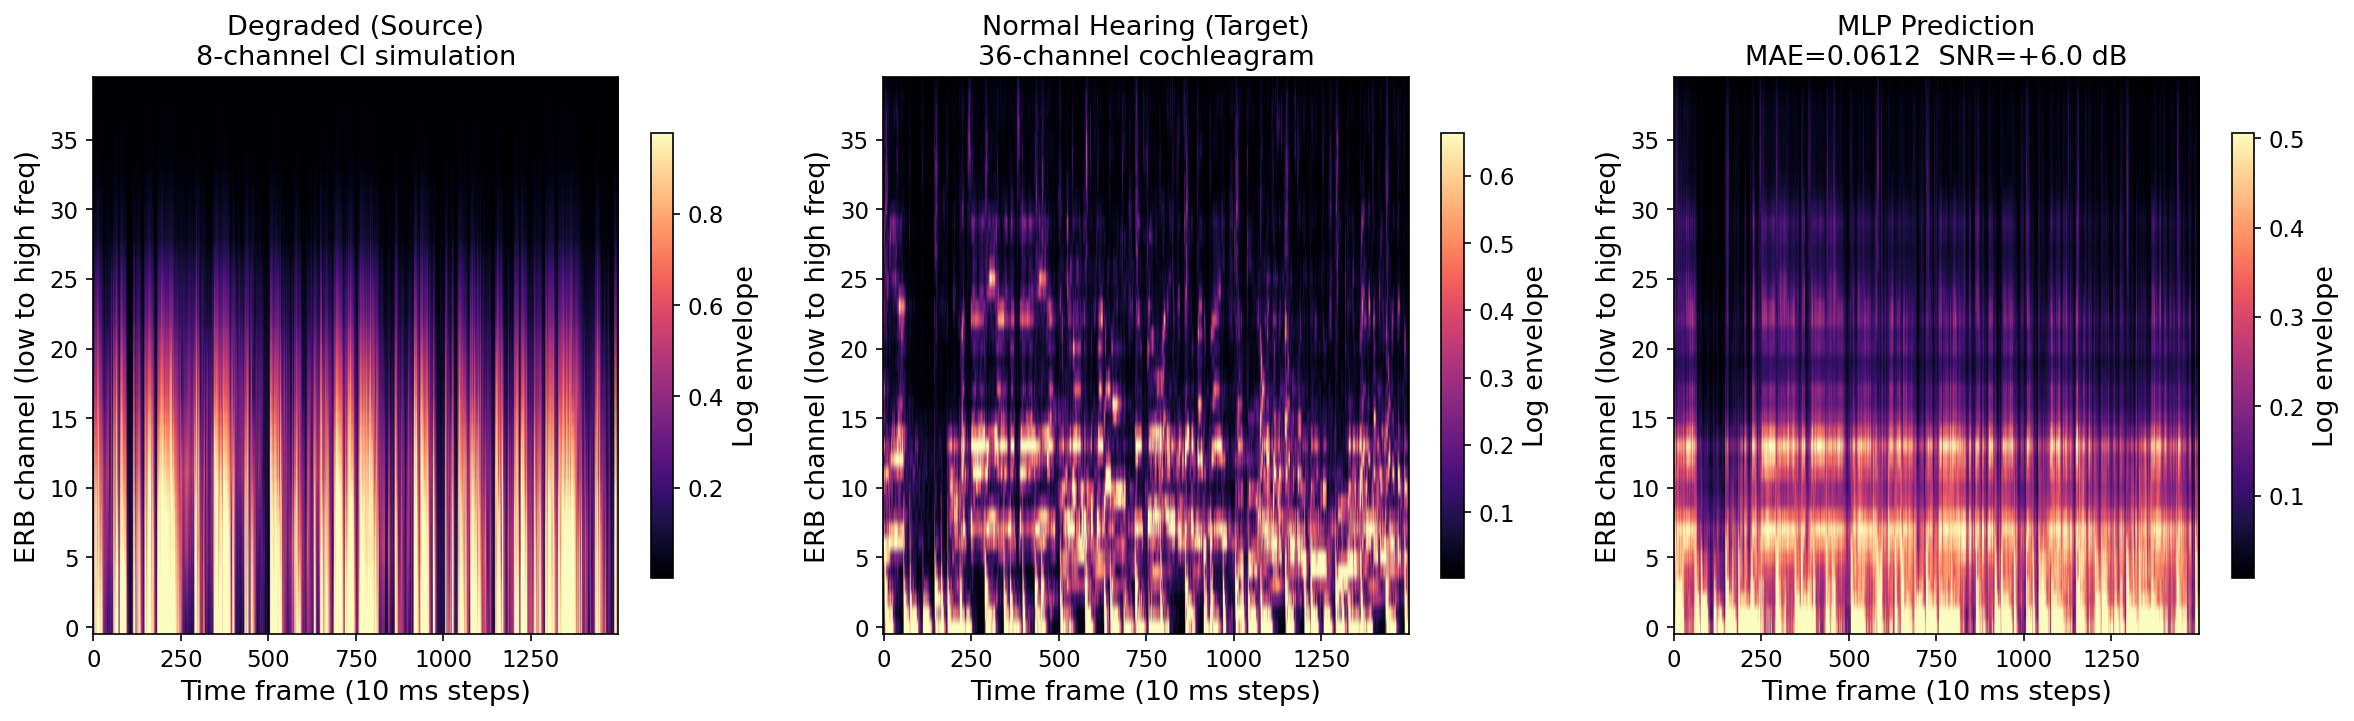

In [ ]:
# PLOT 1 — Main Result
# Source (degraded) | Target (normal) | MLP Prediction
# MLP = most general model: no linearity assumption, learns any function
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
panels = [
    (C_src_aligned, 'Degraded (Source)\n8-channel CI simulation'),
    (C_tgt,         'Normal Hearing (Target)\n36-channel cochleagram'),
    (C_hat_mlp,     f'MLP Prediction\nMAE={res_mlp["mae"]:.4f}  SNR={res_mlp["snr_db"]:+.1f} dB'),
]
for ax, (C, title) in zip(axs, panels):
    vmin, vmax = np.percentile(C, 5), np.percentile(C, 95)
    im = ax.imshow(C[:, i0_sp:i1_sp], aspect='auto', origin='lower',
                   vmin=vmin, vmax=vmax, cmap='magma')
    ax.set_title(title)
    ax.set_xlabel('Time frame (10 ms steps)')
    ax.set_ylabel('ERB channel (low to high freq)')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Log envelope')
# plt.suptitle('Plot 1 — Cochleagram reconstruction: degraded | target | MLP prediction',
#              fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('plot1_main_result.pdf', bbox_inches='tight')
plt.show()


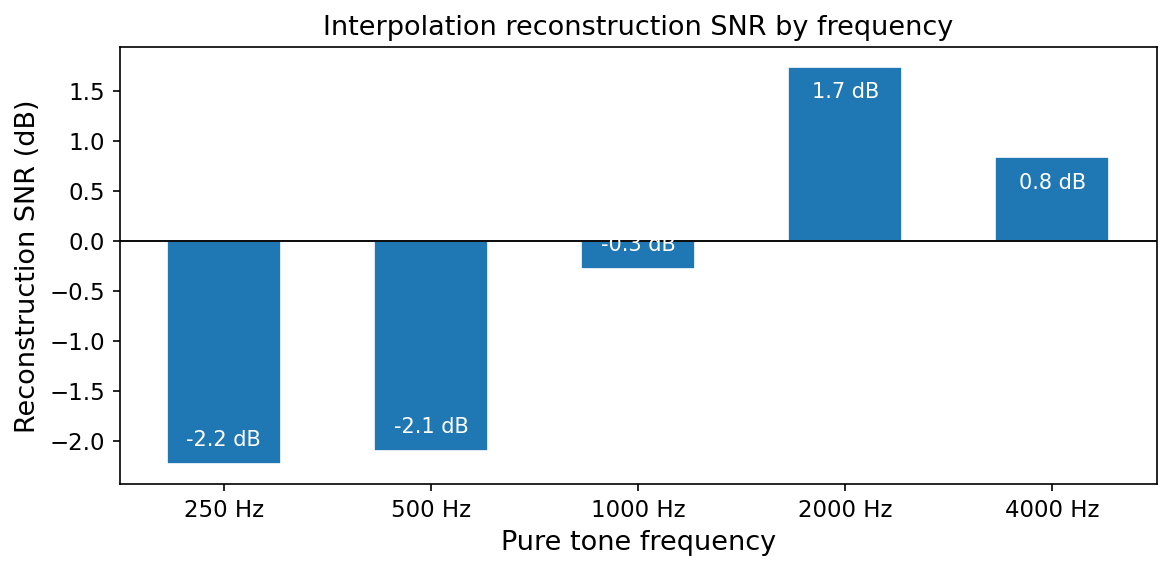

In [77]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    [f'{f} Hz' for f in test_freqs],
    pt_snr_list,
    width=0.55,
    edgecolor='white',
    linewidth=0.8
)

ax.axhline(0, color='black', linestyle='-', linewidth=0.9)

for bar, snr in zip(bars, pt_snr_list):
    y = bar.get_height()
    
    if y >= 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y - 0.15,
            f'{snr:.1f} dB',
            ha='center',
            va='top',
            fontsize=10,
            color='white'
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y + 0.15,
            f'{snr:.1f} dB',
            ha='center',
            va='bottom',
            fontsize=10,
            color='white'
        )
ax.set_xlabel('Pure tone frequency')
ax.set_ylabel('Reconstruction SNR (dB)')
ax.set_title('Interpolation reconstruction SNR by frequency')
plt.tight_layout()
plt.show()

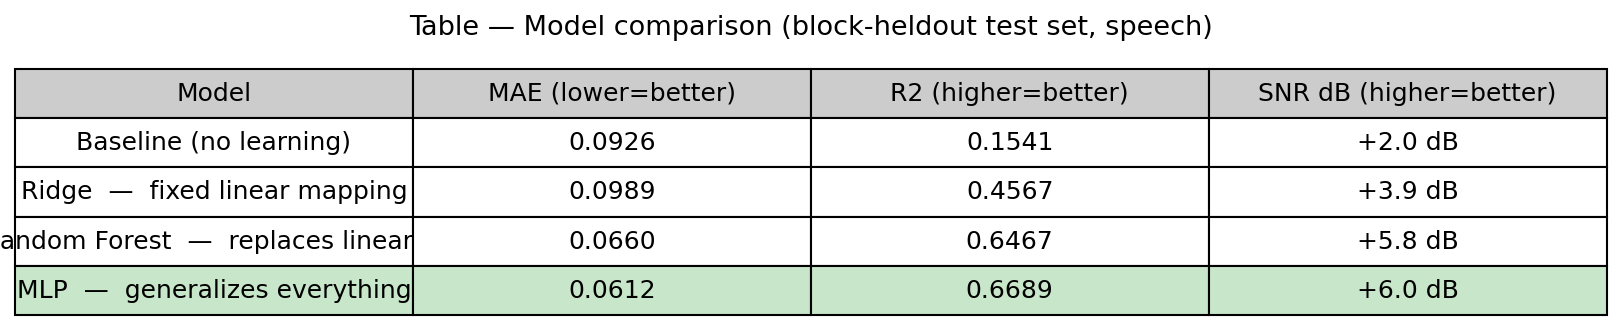

Interpolation SNR  : +2.0 dB
Best learned model : +6.0 dB  (+4.1 dB over baseline)


In [64]:
# TABLE — Model Comparison
# Fixed order: Interpolation -> Ridge -> RF -> MLP, best row green
model_descriptions = {
    'Interpolation only (baseline)':         'Baseline (no learning)',
    'Ridge':                                 'Ridge  —  fixed linear mapping',
    'Random Forest (100 trees, depth=10)':   'Random Forest  —  replaces linearity',
    'MLP (128-64, relu, early stopping)':    'MLP  —  generalizes everything',
}
results_paper = [res_interp, res_ridge, res_rf, res_mlp]
table_data = []
for res in results_paper:
    short = model_descriptions.get(res['name'], res['name'])
    table_data.append([short, f'{res["mae"]:.4f}', f'{res["r2"]:.4f}', f'{res["snr_db"]:+.1f} dB'])

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.axis('off')
col_labels = ['Model', 'MAE (lower=better)', 'R2 (higher=better)', 'SNR dB (higher=better)']
tbl = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1, 2.2)
snr_vals = [float(row[3].replace(' dB', '')) for row in table_data]
best_row = snr_vals.index(max(snr_vals)) + 1
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#CCCCCC')
    tbl[(best_row, j)].set_facecolor('#C8E6C9')
ax.set_title('Table — Model comparison (block-heldout test set, speech)', fontsize=13, pad=16)
plt.tight_layout()
# plt.savefig('table_model_comparison.pdf', bbox_inches='tight')
plt.show()
best_snr = max(r['snr_db'] for r in [res_ridge, res_mlp, res_rf])
print(f'Interpolation SNR  : {res_interp["snr_db"]:+.1f} dB')
print(f'Best learned model : {best_snr:+.1f} dB  (+{best_snr - res_interp["snr_db"]:.1f} dB over baseline)')


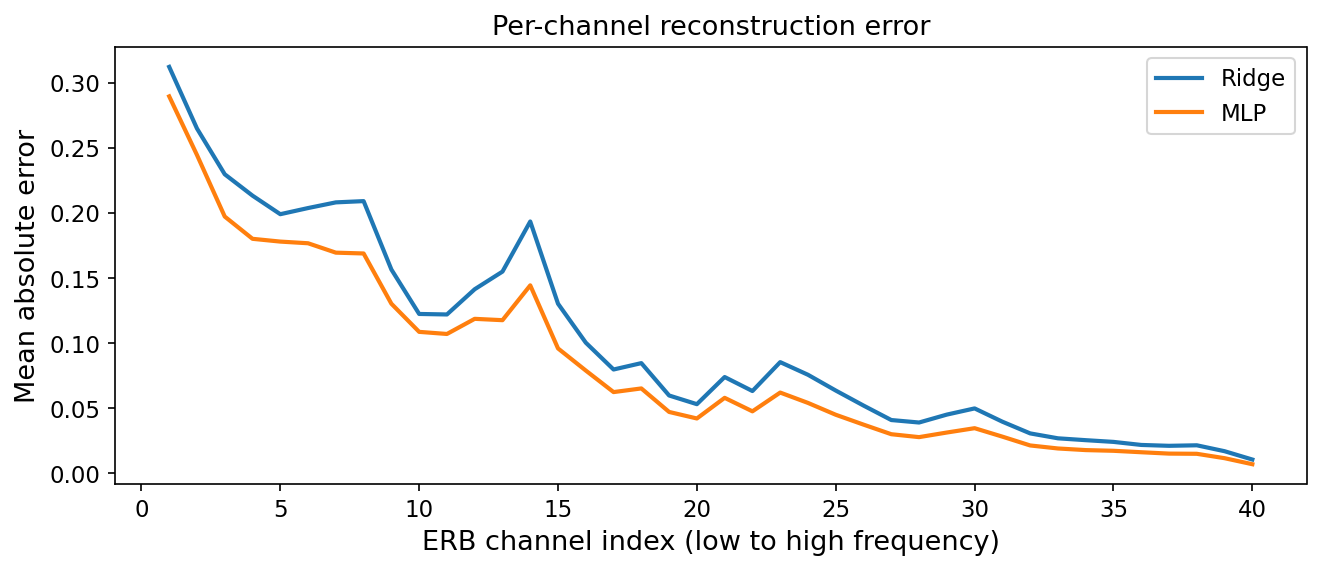

In [ ]:
# Figure — Per-channel reconstruction error
ch = np.arange(1, TGT['N'] + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ch, per_ch_mae_ridge, label='Ridge', linewidth=2)
ax.plot(ch, per_ch_mae_mlp,   label='MLP', linewidth=2)
ax.plot(ch, per_ch_mae_rf,    label='Random Forest',
        linewidth=1.5, linestyle='--', alpha=0.8)

ax.set_xlabel('ERB channel index (low to high frequency)')
ax.set_ylabel('Mean absolute error')
ax.set_title('Per-channel reconstruction error')
ax.legend()
plt.tight_layout()
# plt.savefig('plot3_perchannel_mae.pdf', bbox_inches='tight')
plt.show()

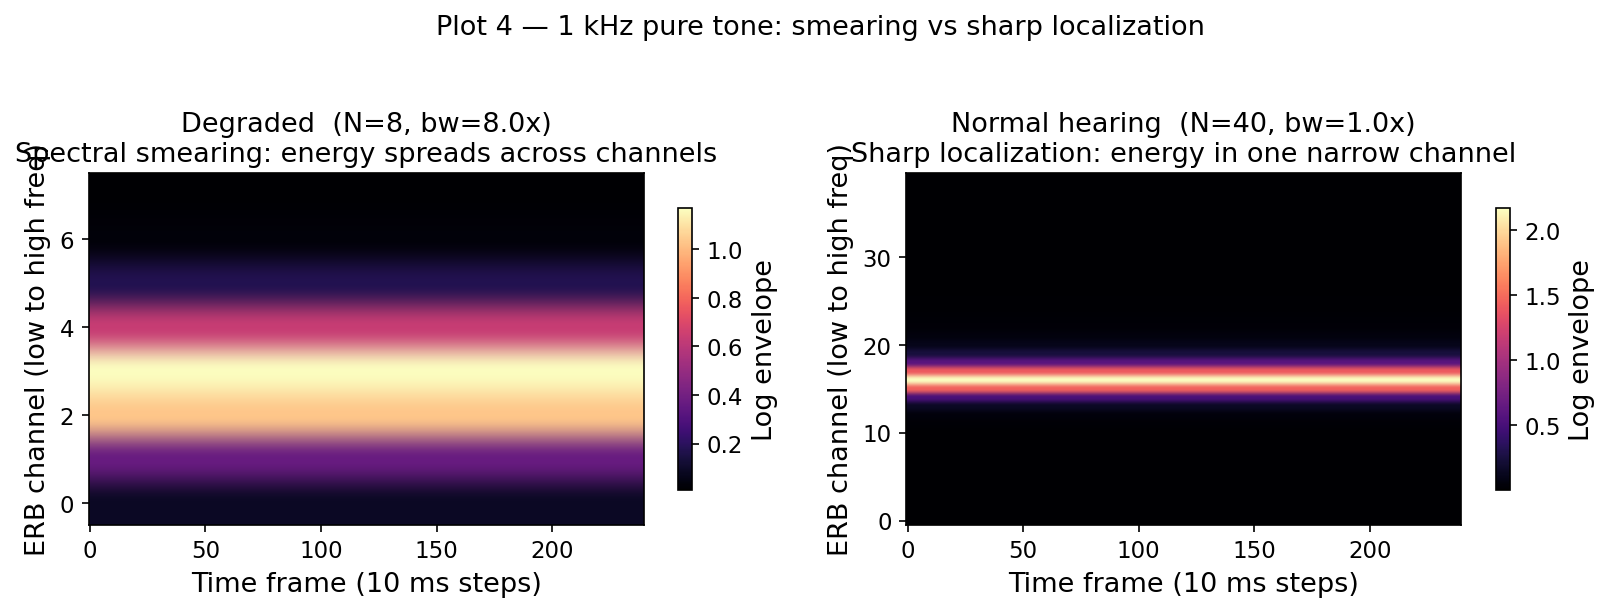

In [ ]:
# PLOT 4 — 1 kHz Pure Tone: Smearing Visible
i0_pt = int(0.1 * fs / hop)
i1_pt = int(2.5 * fs / hop)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, C, title in [
    (axs[0], C_pt_src,
     f'Degraded  (N={SRC["N"]}, bw={SRC["bw_mult"]}x)\n'
      'Spectral smearing: energy spreads across channels'),
    (axs[1], C_pt_tgt,
     f'Normal hearing  (N={TGT["N"]}, bw={TGT["bw_mult"]}x)\n'
      'Sharp localization: energy in one narrow channel'),
]:
    vmin, vmax = np.percentile(C, 2), np.percentile(C, 98)
    im = ax.imshow(C[:, i0_pt:i1_pt], aspect='auto', origin='lower',
                   vmin=vmin, vmax=vmax, cmap='magma')
    ax.set_title(title)
    ax.set_xlabel('Time frame (10 ms steps)')
    ax.set_ylabel('ERB channel (low to high freq)')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Log envelope')
plt.suptitle('Plot 4 — 1 kHz pure tone: smearing vs sharp localization',
             fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('plot4_puretone_smearing.pdf', bbox_inches='tight')
plt.show()


  Freq    Interp     Ridge       MLP        RF
------------------------------------------------
   250      -2.2     +14.3     +15.3     +15.7
   500      -2.1     +16.3     +18.4     +14.1
  1000      -0.3      +7.9      -4.8     +13.4
  2000      +1.7     +13.1      +3.2     +12.9
  4000      +0.8     +14.3     +12.6     +13.0


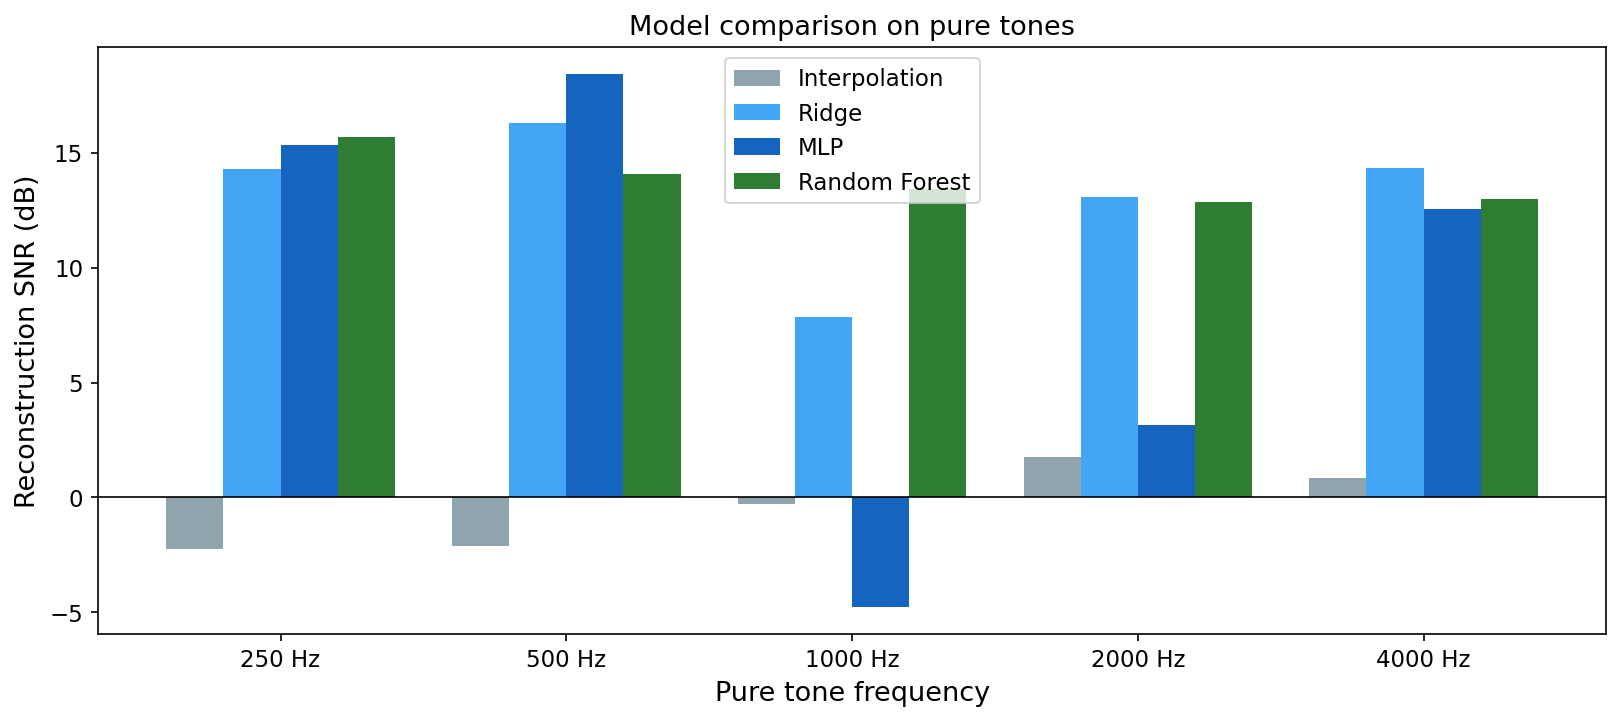

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

ridge_snr = []
mlp_snr = []
rf_snr = []

print(f'{"Freq":>6}  {"Interp":>8}  {"Ridge":>8}  {"MLP":>8}  {"RF":>8}')
print('-' * 48)

for freq, interp_val in zip(test_freqs, pt_snr_list):
    tone = np.sin(2 * np.pi * freq * t_sweep)

    bad_tone, _, _ = build_cochleagram(tone, fs, N=SRC['N'], bw_mult=SRC['bw_mult'])
    good_tone, _, _ = build_cochleagram(tone, fs, N=TGT['N'], bw_mult=TGT['bw_mult'])

    n_frames = min(bad_tone.shape[1], good_tone.shape[1])
    bad_tone = bad_tone[:, :n_frames]
    good_tone = good_tone[:, :n_frames]

    bad_tone_aligned = interp1d(
        centers_src,
        bad_tone,
        axis=0,
        kind='linear',
        fill_value='extrapolate'
    )(centers_tgt)

    split_idx = int(0.8 * bad_tone_aligned.shape[1])

    x_raw = bad_tone_aligned.T
    y_raw = good_tone.T

    x_train_raw = x_raw[:split_idx]
    x_test_raw = x_raw[split_idx:]
    y_train_raw = y_raw[:split_idx]
    y_test_raw = y_raw[split_idx:]

    x_mean = x_train_raw.mean(axis=0, keepdims=True)
    x_std = x_train_raw.std(axis=0, keepdims=True) + 1e-8
    y_mean = y_train_raw.mean(axis=0, keepdims=True)
    y_std = y_train_raw.std(axis=0, keepdims=True) + 1e-8

    x_train = (x_train_raw - x_mean) / x_std
    x_test = (x_test_raw - x_mean) / x_std
    y_train = (y_train_raw - y_mean) / y_std

    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(x_train, y_train)
    ridge_pred = ridge_model.predict(x_test) * y_std + y_mean
    ridge_val = recon_snr(ridge_pred, y_test_raw)
    ridge_snr.append(ridge_val)

    mlp_model = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.1,
        random_state=0,
        verbose=False
    )
    mlp_model.fit(x_train, y_train)
    mlp_pred = mlp_model.predict(x_test) * y_std + y_mean
    mlp_val = recon_snr(mlp_pred, y_test_raw)
    mlp_snr.append(mlp_val)

    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0)
    rf_model.fit(x_train, y_train)
    rf_pred = rf_model.predict(x_test) * y_std + y_mean
    rf_val = recon_snr(rf_pred, y_test_raw)
    rf_snr.append(rf_val)

    print(f'{freq:>6}  {interp_val:>+8.1f}  {ridge_val:>+8.1f}  {mlp_val:>+8.1f}  {rf_val:>+8.1f}')

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(test_freqs))
w = 0.2

ax.bar(x - 1.5*w, pt_snr_list, width=w, label='Interpolation', color='#90A4AE')
ax.bar(x - 0.5*w, ridge_snr,   width=w, label='Ridge',         color='#42A5F5')
ax.bar(x + 0.5*w, mlp_snr,     width=w, label='MLP',           color='#1565C0')
ax.bar(x + 1.5*w, rf_snr,      width=w, label='Random Forest', color='#2E7D32')

ax.axhline(0, color='black', linestyle='-', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'{f} Hz' for f in test_freqs])
ax.set_xlabel('Pure tone frequency')
ax.set_ylabel('Reconstruction SNR (dB)')
ax.set_title('Model comparison on pure tones')
ax.legend()

plt.tight_layout()
# plt.savefig('appendix_puretone_model_comparison.pdf', bbox_inches='tight')
plt.show()

---
## 7. Interpreting the Results

### What each metric means

**MAE** — average error per time-frequency cell. Compare to the interpolation baseline. If your model MAE equals interpolation MAE, it learned nothing.

**R²** — proportion of target variance explained.
- `1.0` = perfect reconstruction
- `0.0` = model just predicts the channel mean (useless)
- Negative = something is very wrong

**SNR (dB)** — standard signal processing metric.
- `> 20 dB` = excellent
- `10–20 dB` = good, spectral structure preserved
- `0–10 dB` = poor, significant distortion
- `< 0 dB` = reconstruction is mostly noise

### What the results actually say

The key comparison is **interpolation SNR vs best model SNR**. If the best model is meaningfully higher (>2 dB), there is systematic spectral information in the degraded cochleagram that a learned model can exploit. That is the core scientific claim.

### What the pure tone test says

Plot 2 shows where information is lost. Low SNR at high frequencies means even a pure tone cannot be well-recovered by interpolation there — a fundamental limit of wide CI filters. ML models can partially correct this by learning the gain structure, but cannot recover information that was never encoded.

### On the model ranking

The ranking of Ridge / MLP / RF matters less than the gap over interpolation. On a single recording, RF and MLP can overfit to this file's temporal statistics. **Ridge is the safest generalizer** — if Ridge beats interpolation, the result is robust.
